Run mlserver with the following command:

mlflow server \
    --backend-store-uri sqlite:///mlruns.db \
    --default-artifact-root ./mlruns \
    --host 0.0.0.0 \
    --port 5000

then execute the notebook

we will be using the dataset with the variables for vowels, that is the result of the notebook 2024_07_19_exploratory_data_analysis.ipynb. the name is no_nulls_dataset.csv


In [1]:
import os
from pathlib import Path
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import mlflow

# Esto es para poder importar las funciones de src
os.chdir('/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos')

In [2]:
from datetime import datetime
import time
import mlflow

# Set MLflow tracking URI
mlflow.set_tracking_uri('http://localhost:5000')

# Create an experiment if it doesn't exist
experiment_name = f"Age Prediction Experiment {datetime.now().strftime('%Y-%m-%d_%H-%M')}"
try:
    # mlflow.create_experiment(experiment_name)
    mlflow.set_experiment(experiment_name)
except mlflow.exceptions.MlflowException as e:
    # If the experiment already exists, you can catch the exception and continue
    print(f"Experiment '{experiment_name}' already exists.")

# Start an MLflow experiment
mlflow.start_run(run_name="Age Prediction Experiment - Voice Vowels - V3", experiment_id="0")

start_time = time.time()



2025/02/17 02:48:47 INFO mlflow.tracking.fluent: Experiment with name 'Age Prediction Experiment 2025-02-17_02-48' does not exist. Creating a new experiment.


In [3]:
dataset = Path("/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv")
df = pd.read_csv(dataset)

mlflow.log_param("initial_data_path", str(dataset))


'/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv'

In [4]:
df.head()

,file,label,f0_mean,f1_mean,f2_mean,f3_mean,intensity_mean,jitter_local,shimmer_local,f0_median,...,health-voicevow-m,health-voicevow-all,trust-voicesent-f,trust-voicesent-m,trust-voicesent-all,trust-voicevow-f,trust-voicevow-m,trust-voicevow-all,age,sex
0,M-300_VoiceVowel.wav,M-300,122.322069,635.195806,1767.373862,3043.066290,58.393201,0.030243,0.089393,108.702278,...,65.4,71.2,61.7,43.5,52.2,78.9,58.8,68.4,21,Male
1,M-337_VoiceVowel.wav,M-337,128.490284,609.408444,1657.802047,2873.230920,54.146626,0.022896,0.126083,112.885902,...,77.0,75.9,45.0,47.6,46.3,59.5,66.1,62.8,20,Male
2,F-163_VoiceVowel.wav,F-163,244.779671,778.045595,1912.752299,3162.830370,57.474203,0.011711,0.105925,243.676692,...,72.1,68.5,51.8,45.9,48.9,57.2,61.6,59.4,21,Female
3,F-329_VoiceVowel.wav,F-329,248.108167,647.491493,1760.853414,2908.456272,55.920847,0.021368,0.090407,243.117655,...,58.7,60.0,43.9,41.7,42.7,52.9,51.3,52.0,21,Female
4,F-154_VoiceVowel.wav,F-154,244.347591,628.516425,1663.641613,3071.155453,52.288688,0.025479,0.133791,241.240378,...,50.7,55.3,64.9,61.2,63.1,57.9,62.2,60.0,18,Female


# Feature Engineering

Let's map the gender to 0 and 1

In [5]:
# Map gender to 0 and 1
df.loc[:, "sex_numeric"] = df["sex"].map({"Male": 0.0, "Female": 1.0})

Let's create a new column with the age category balanced, calculated by the quantiles of the age column.

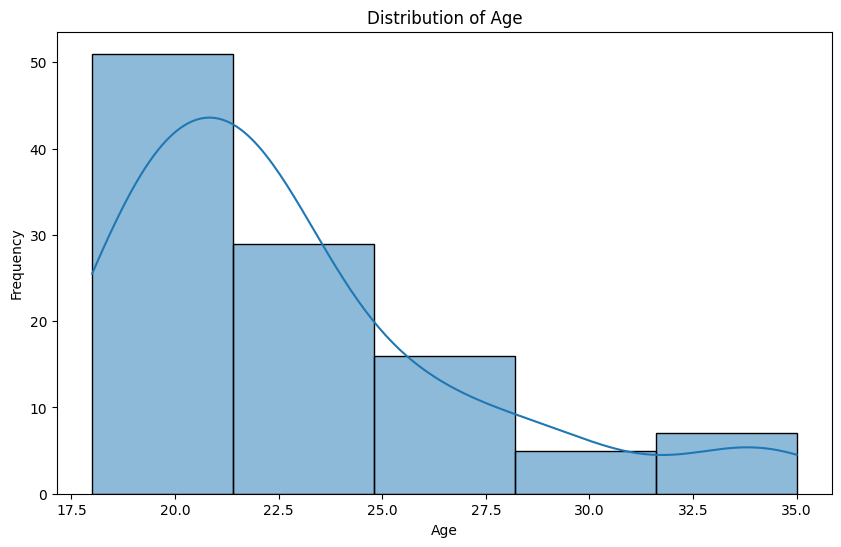

In [6]:
# Data Visualization of the age distribution

import seaborn as sns
# Plot the distribution of the age category

plt.figure(figsize=(10, 6))
sns.histplot(df["age"], bins=5, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [7]:
import numpy as np


# Calculate quantiles for dividing into thirds
quantiles = df['age'].quantile([0.33, 0.66]).to_dict()

def categorize_age(age):
    if age <= quantiles[0.33]:
        return '10-20'
    elif age <= quantiles[0.66]:
        return '21-23'
    else:
        return '24-39'

# Apply the function to create the new column
df['age_category_balanced'] = df['age'].apply(categorize_age)

# Verify the distribution
print(df['age_category_balanced'].value_counts())

age_category_balanced
21-23    42
10-20    36
24-39    30
Name: count, dtype: int64


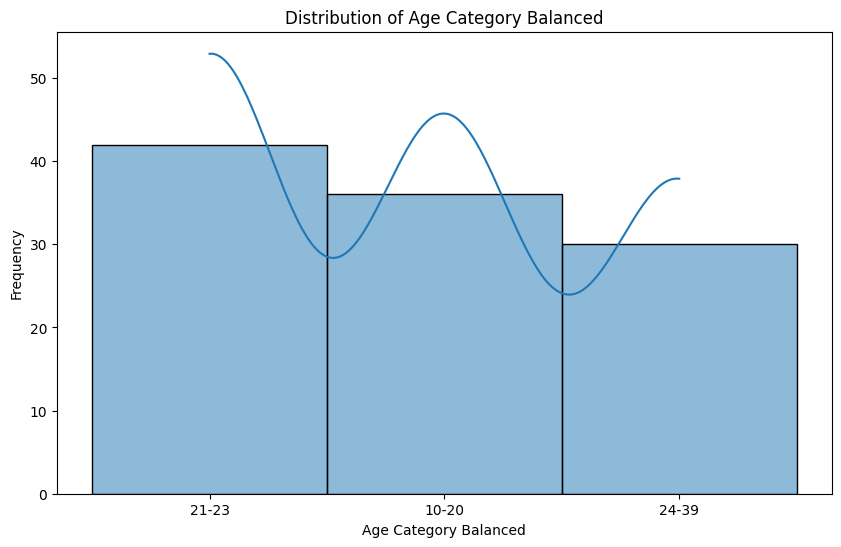

In [8]:
# Data Visualization

import seaborn as sns
# Plot the distribution of the age category

plt.figure(figsize=(10, 6))
sns.histplot(df["age_category_balanced"], bins=5, kde=True)
plt.title("Distribution of Age Category Balanced")
plt.xlabel("Age Category Balanced")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Map age category to numeric
df.loc[:, "age_category_numeric"] = df["age_category_balanced"].map({"10-20": 0, "21-23": 1, "24-39": 2})


In [10]:
df["age_category_numeric"].value_counts()

age_category_numeric
1    42
0    36
2    30
Name: count, dtype: int64

### Spectrogram features


Now, we will create the spectrogram features. We will use the function compute_mel_spec to create the spectrogram features. These features will be used to train the model.

In [11]:
import os
import librosa

def resize_spectrogram(spec, length, fact=-80):

    # Create an empty canvas to put spectrogram into
    canvas = np.ones((len(spec), length)) * fact

    if spec.shape[1] <= length:
        canvas[:, : spec.shape[1]] = spec
    else:
        canvas[:, :length] = spec[:, :length]
    return canvas

def compute_mel_spec(filename, sr=16000, hop_length=512, duration=3.0):

    # Loads the mp3 file
    y, sr = librosa.load(os.path.join("audio_dataset", filename), sr=sr)

    # Compute the mel spectrogram
    x_mel = librosa.feature.melspectrogram(y=y, sr=sr)

    # Apply logarithmic dB-scale to spectrogram and set maximum to 0 dB
    x_mel = librosa.power_to_db(x_mel, ref=np.max)

    # Compute mean strength per frequency for mel spectrogram
    mel_strength = np.mean(x_mel, axis=1)

    # Estimate the desired length of the spectrogram
    length = int(duration * sr / hop_length)

    # Put mel spectrogram into the right shape
    x_mel = resize_spectrogram(x_mel, length, fact=-80)

    return x_mel, mel_strength

In [12]:
# instantiate feature extractor
from ml_project.components.preprocessing.mel_spec_feature_extractor import MelFeatureExtractor
import numpy as np


# Create arrays to store output into
spec_infos = []

# Loop through all files and extract spectrograms
sr = 16000
for f in df.file:
    folder = f.split(".")[0]
    f = Path("/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01") / folder / f
    print(f"Processing file {f}")
    spec_infos.append(compute_mel_spec(f, sr=sr))

# Aggregate feature types in common variable
mels = np.array([s[0] for s in spec_infos])
mels_strengths = np.array([s[1] for s in spec_infos])

Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-300_VoiceVowel/M-300_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-337_VoiceVowel/M-337_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-163_VoiceVowel/F-163_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-329_VoiceVowel/F-329_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-154_VoiceVowel/F-154_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-289_VoiceV

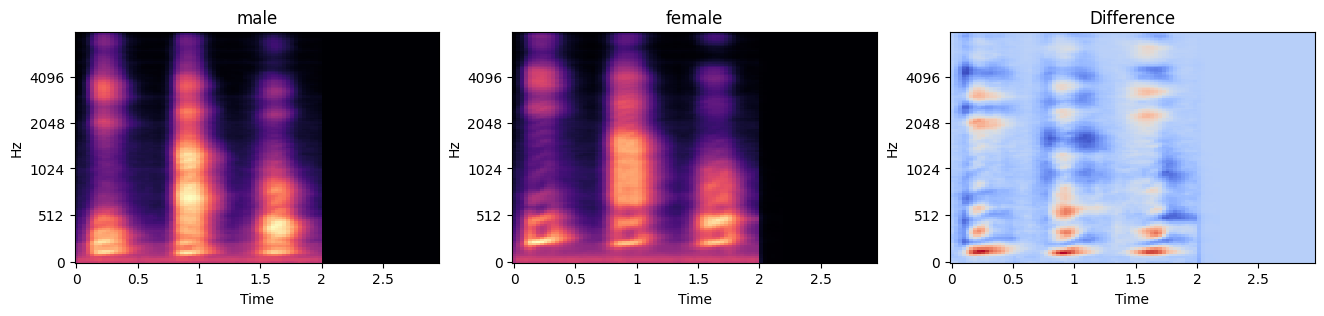

In [13]:
import librosa.display

# Creates a figure with two subplot
fig, axs = plt.subplots(1, 3, figsize=(16, 3))

# Plots mel spectrogram for male speakers
mels_male = np.mean(mels[df["sex_numeric"].eq(0)], axis=0)
librosa.display.specshow(mels_male, sr=sr, x_axis="time", y_axis="mel", ax=axs[0])
axs[0].set_title("male")

# Plots mel spectrogram for female speakers
mels_female = np.mean(mels[df["sex_numeric"].eq(1)], axis=0)
librosa.display.specshow(mels_female, sr=sr, x_axis="time", y_axis="mel", ax=axs[1])
axs[1].set_title("female")

# Plot gender differences
librosa.display.specshow(
    mels_male - mels_female, sr=sr, x_axis="time", y_axis="mel", ax=axs[2]
)
axs[2].set_title("Difference")
plt.show()

# Machine learning models

Goal: predict the age category based on the spectrogram features and dataset features

## Shallow ML Model

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   file                   108 non-null    object 
 1   label                  108 non-null    object 
 2   f0_mean                108 non-null    float64
 3   f1_mean                108 non-null    float64
 4   f2_mean                108 non-null    float64
 5   f3_mean                108 non-null    float64
 6   intensity_mean         108 non-null    float64
 7   jitter_local           108 non-null    float64
 8   shimmer_local          108 non-null    float64
 9   f0_median              108 non-null    float64
 10  f0_std                 108 non-null    float64
 11  sample_name            108 non-null    object 
 12  attrac-voicesent-f     108 non-null    float64
 13  attrac-voicesent-m     108 non-null    float64
 14  attrac-voicesent-all   108 non-null    float64
 15  attrac

In [15]:
# create df_features
df_features = df.drop(columns=["file", "label", "sample_name", "sex", "age", "age_category_balanced"])
df_features.head()

,f0_mean,f1_mean,f2_mean,f3_mean,intensity_mean,jitter_local,shimmer_local,f0_median,f0_std,attrac-voicesent-f,...,health-voicevow-m,health-voicevow-all,trust-voicesent-f,trust-voicesent-m,trust-voicesent-all,trust-voicevow-f,trust-voicevow-m,trust-voicevow-all,sex_numeric,age_category_numeric
0,122.322069,635.195806,1767.373862,3043.066290,58.393201,0.030243,0.089393,108.702278,49.581469,59.3,...,65.4,71.2,61.7,43.5,52.2,78.9,58.8,68.4,0.0,1
1,128.490284,609.408444,1657.802047,2873.230920,54.146626,0.022896,0.126083,112.885902,69.195320,38.5,...,77.0,75.9,45.0,47.6,46.3,59.5,66.1,62.8,0.0,0
2,244.779671,778.045595,1912.752299,3162.830370,57.474203,0.011711,0.105925,243.676692,17.893914,32.7,...,72.1,68.5,51.8,45.9,48.9,57.2,61.6,59.4,1.0,1
3,248.108167,647.491493,1760.853414,2908.456272,55.920847,0.021368,0.090407,243.117655,25.149248,20.2,...,58.7,60.0,43.9,41.7,42.7,52.9,51.3,52.0,1.0,1
4,244.347591,628.516425,1663.641613,3071.155453,52.288688,0.025479,0.133791,241.240378,18.864380,65.3,...,50.7,55.3,64.9,61.2,63.1,57.9,62.2,60.0,1.0,0


In [16]:
df_features.head()

,f0_mean,f1_mean,f2_mean,f3_mean,intensity_mean,jitter_local,shimmer_local,f0_median,f0_std,attrac-voicesent-f,...,health-voicevow-m,health-voicevow-all,trust-voicesent-f,trust-voicesent-m,trust-voicesent-all,trust-voicevow-f,trust-voicevow-m,trust-voicevow-all,sex_numeric,age_category_numeric
0,122.322069,635.195806,1767.373862,3043.066290,58.393201,0.030243,0.089393,108.702278,49.581469,59.3,...,65.4,71.2,61.7,43.5,52.2,78.9,58.8,68.4,0.0,1
1,128.490284,609.408444,1657.802047,2873.230920,54.146626,0.022896,0.126083,112.885902,69.195320,38.5,...,77.0,75.9,45.0,47.6,46.3,59.5,66.1,62.8,0.0,0
2,244.779671,778.045595,1912.752299,3162.830370,57.474203,0.011711,0.105925,243.676692,17.893914,32.7,...,72.1,68.5,51.8,45.9,48.9,57.2,61.6,59.4,1.0,1
3,248.108167,647.491493,1760.853414,2908.456272,55.920847,0.021368,0.090407,243.117655,25.149248,20.2,...,58.7,60.0,43.9,41.7,42.7,52.9,51.3,52.0,1.0,1
4,244.347591,628.516425,1663.641613,3071.155453,52.288688,0.025479,0.133791,241.240378,18.864380,65.3,...,50.7,55.3,64.9,61.2,63.1,57.9,62.2,60.0,1.0,0


Select target variable and combine features with mels strength features

In [17]:
# Select target
target = "age_category_numeric"
y = df_features[target].values

#df_features.columns = df_features.columns.astype(str)

# Combine them with the mels strength features
X = pd.concat((df_features, pd.DataFrame(mels_strengths)), axis=1)

# Convert all columns names to string, otherwise the model will not work and will throw an error
X.columns = X.columns.astype(str)

print(f"Amount of features: {len(X.columns)}")

Amount of features: 169


In [18]:
pd.Series(y).value_counts()

1    42
0    36
2    30
Name: count, dtype: int64

Target values are balanced now!

### Split the data into train, and test sets

In [19]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split into train, test, and validation sets
x_tr, x_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.8, shuffle=True, stratify=y, random_state=0
)

# Print dataset sizes
print(f"Train set size: {x_tr.shape}")
print(f"Train set class distribution: \n{pd.Series(y_tr).value_counts()}")
print(f"Test set size: {x_te.shape}")
print(f"Test set class distribution: \n{pd.Series(y_te).value_counts()}")

Train set size: (86, 169)
Train set class distribution: 
1    33
0    29
2    24
Name: count, dtype: int64
Test set size: (22, 169)
Test set class distribution: 
1    9
0    7
2    6
Name: count, dtype: int64


In [20]:

# Log the size of the train and test sets
mlflow.log_param("train_set_size", x_tr.shape)
mlflow.log_param("train_set_class_distribution", pd.Series(y_tr).value_counts().sort_index())
mlflow.log_param("test_set_size", x_te.shape)
mlflow.log_param("test_set_class_distribution", pd.Series(y_te).value_counts().sort_index())


0    7
1    9
2    6
Name: count, dtype: int64

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np

# Define the categorical and numerical columns
categorical_features = ["age_category_numeric"]
numerical_features = [col for col in df_features.columns if col != "age_category_numeric"]  # Exclude the categorical column

# Create the ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first"), categorical_features),
        ("num", RobustScaler(), numerical_features),
    ]
)

# Modify the pipeline to use Random Forest instead of Logistic Regression
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),  # Preprocessing step
        ("rf", RandomForestClassifier(class_weight="balanced")),  # Random Forest model
    ]
)

# Update the hyperparameter grid for Random Forest
grid = {
    "preprocessor__num": [RobustScaler(), PowerTransformer()],
    "rf__n_estimators": [10, 25, 50, 100, 200],  # Number of trees in the forest
    "rf__max_depth": [None, 5,10, 20],     # Maximum depth of trees
    "rf__min_samples_split": [2, 5, 10], # Minimum samples required to split an internal node
    "rf__min_samples_leaf": [1, 2, 4],   # Minimum samples required at a leaf node
}

# Create GridSearchCV object for hyperparameter tuning with cross-validation
grid_cv = GridSearchCV(pipe, grid, cv=StratifiedKFold(n_splits=4), return_train_score=True, verbose=1)

In [32]:
mlflow.log_param("grid_search_parameters", grid)

{'preprocessor__num': [RobustScaler(), PowerTransformer()],
 'rf__n_estimators': [10, 25, 50, 100, 200],
 'rf__max_depth': [None, 5, 10, 20],
 'rf__min_samples_split': [2, 5, 10],
 'rf__min_samples_leaf': [1, 2, 4]}

In [33]:
# Train GridSearchCV
model = grid_cv.fit(x_tr, y_tr)

Fitting 4 folds for each of 360 candidates, totalling 1440 fits


In [34]:
# Log cross-validation metrics
cv_results = model.cv_results_
for i in range(len(cv_results['params'])):
    with mlflow.start_run(nested=True):
        mlflow.log_params(cv_results['params'][i])
        mlflow.log_metric("mean_test_score", 
                         cv_results['mean_test_score'][i])

🏃 View run shivering-conch-557 at: http://localhost:5000/#/experiments/28/runs/a87d3acb073544ae904f0f9472cf747e
🧪 View experiment at: http://localhost:5000/#/experiments/28
🏃 View run shivering-trout-133 at: http://localhost:5000/#/experiments/28/runs/f4b905773d5543fca8f708625bb5a0f7
🧪 View experiment at: http://localhost:5000/#/experiments/28
🏃 View run mysterious-jay-323 at: http://localhost:5000/#/experiments/28/runs/405b7fa017bf4983a7826cc89b51db9a
🧪 View experiment at: http://localhost:5000/#/experiments/28
🏃 View run caring-frog-422 at: http://localhost:5000/#/experiments/28/runs/caeacb5873204715bcfdeacb381d0060
🧪 View experiment at: http://localhost:5000/#/experiments/28
🏃 View run auspicious-crab-66 at: http://localhost:5000/#/experiments/28/runs/93c7612d17264baab5631795d2b5f71b
🧪 View experiment at: http://localhost:5000/#/experiments/28
🏃 View run colorful-midge-563 at: http://localhost:5000/#/experiments/28/runs/3520f1f0da224727850841f2be6ee8fd
🧪 View experiment at: http://l

In [35]:
from mlflow.models.signature import infer_signature

 # Infer model signature
signature = infer_signature(x_tr, model.predict(x_tr))

# Register the model
mlflow.sklearn.log_model(sk_model=model, artifact_path="model", signature=signature)

/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/venv/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [37]:
mlflow.log_metric("best_score", model.best_score_)

# For logging the best parameters, you need to convert them into a string or log them individually
best_params = model.best_params_
for param, value in best_params.items():
    mlflow.log_param(param, value)

mlflow.log_param("best_estimator", str(model.best_estimator_))

MlflowException: INVALID_PARAMETER_VALUE: Changing param values is not allowed. Param with key='rf__min_samples_leaf' was already logged with value='1' for run ID='0b88647f97324af99835216d85ba8069'. Attempted logging new value '2'.

The cause of this error is typically due to repeated calls
to an individual run_id event logging.

Incorrect Example:
---------------------------------------
with mlflow.start_run():
    mlflow.log_param("depth", 3)
    mlflow.log_param("depth", 5)
---------------------------------------

Which will throw an MlflowException for overwriting a
logged parameter.

Correct Example:
---------------------------------------
with mlflow.start_run():
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 3)
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 5)
---------------------------------------

Which will create a new nested run for each individual
model and prevent parameter key collisions within the
tracking store.

In [38]:
# Select the columns we are interested in for Random Forest
col_of_interest = [
    "param_preprocessor__num",  # Preprocessing scaler
    "param_rf__n_estimators",   # Number of trees
    "param_rf__max_depth",      # Maximum depth of trees
    "param_rf__min_samples_split",  # Minimum samples to split a node
    "param_rf__min_samples_leaf",   # Minimum samples at a leaf node
    "mean_test_score",          # Mean test score from cross-validation
    "mean_train_score",         # Mean train score from cross-validation
    "std_test_score",           # Standard deviation of test scores
    "std_train_score",          # Standard deviation of train scores
]

# Collect results in a DataFrame
cv_results = pd.DataFrame(grid_cv.cv_results_)
cv_results = cv_results[col_of_interest]

# Show the dataframe sorted according to our performance metric (mean_test_score)
cv_results.sort_values("mean_test_score", ascending=False, inplace=True)

### Print Training and Test Curves

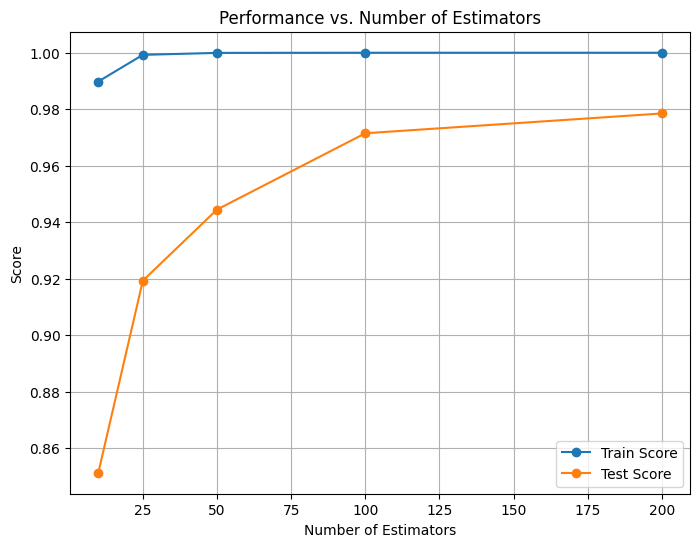

In [41]:
import matplotlib.pyplot as plt

# Select only numeric columns for grouping
numeric_columns = [
    "mean_test_score",
    "mean_train_score",
    "std_test_score",
    "std_train_score"
]

# Group by n_estimators and calculate mean scores
grouped = cv_results.groupby("param_rf__n_estimators")[numeric_columns].mean()

# Plot mean train and test scores
f = plt.figure(figsize=(8, 6))
plt.plot(grouped.index, grouped["mean_train_score"], label="Train Score", marker="o")
plt.plot(grouped.index, grouped["mean_test_score"], label="Test Score", marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Score")
plt.title("Performance vs. Number of Estimators")
plt.legend()
plt.grid(True)
plt.show()

mlflow.log_figure(f, "performance_vs_n_estimators.png")


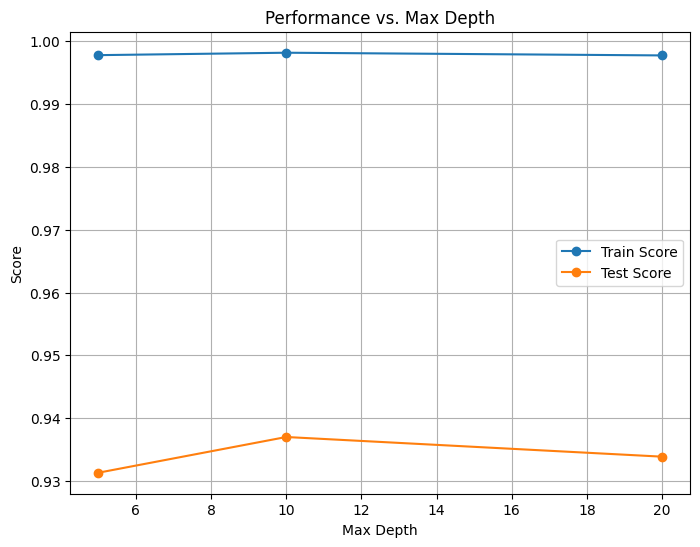

In [44]:
# Select only numeric columns for aggregation
numeric_columns = [
    "mean_test_score",
    "mean_train_score",
    "std_test_score",
    "std_train_score"
]

# Group by max_depth and calculate mean scores
grouped = cv_results.groupby("param_rf__max_depth")[numeric_columns].mean()

# Plot mean train and test scores
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(grouped.index, grouped["mean_train_score"], label="Train Score", marker="o")
plt.plot(grouped.index, grouped["mean_test_score"], label="Test Score", marker="o")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Performance vs. Max Depth")
plt.legend()
plt.grid(True)
plt.show()


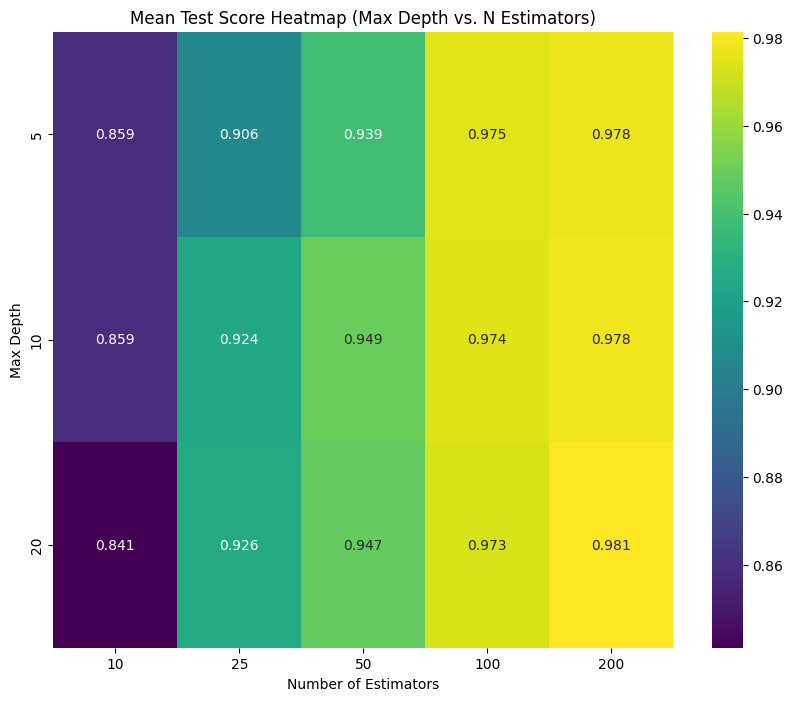

In [43]:
import seaborn as sns

# Pivot table for heatmap (e.g., max_depth vs. n_estimators)
heatmap_data = cv_results.pivot_table(
    values="mean_test_score",
    index="param_rf__max_depth",
    columns="param_rf__n_estimators",
)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean Test Score Heatmap (Max Depth vs. N Estimators)")
plt.xlabel("Number of Estimators")
plt.ylabel("Max Depth")
plt.show()


In [45]:
#log duration of the experiment
mlflow.log_param("duration", time.time() - start_time)

mlflow.end_run(status="FINISHED")

🏃 View run Age Prediction Experiment - Voice Vowels - V3 at: http://localhost:5000/#/experiments/0/runs/0b88647f97324af99835216d85ba8069
🧪 View experiment at: http://localhost:5000/#/experiments/0


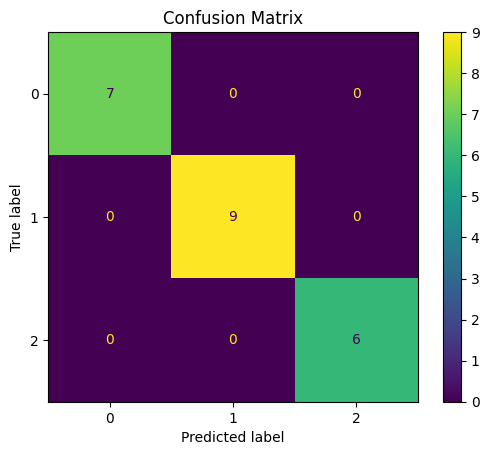

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Extract the best model
best_model = grid_cv.best_estimator_

# Step 2: Make predictions on the test set
y_pred = best_model.predict(x_te)

# Step 3: Compute the confusion matrix
cm = confusion_matrix(y_te, y_pred)

# Step 4: Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="viridis")  # You can change the colormap if desired
plt.title("Confusion Matrix")
plt.show()


In [47]:
# Print the best parameters
print("Best Parameters:", grid_cv.best_params_)


Best Parameters: {'preprocessor__num': RobustScaler(), 'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}


In [48]:
print("Best Score:", grid_cv.best_score_)


Best Score: 1.0
